# Good noise pulses overlaid — series 07221203_2025

Follow-up to `dump1_noise_pulses.ipynb`: take the traces that passed the "good noise"
cut there (`good_noise_traces.csv` — 21 traces, `BASELINE_STD_CAP=5`,
`GOOD_RATIO_THRESH=2.45`) and overlay them on one axis, all baseline-subtracted, to see
how consistent they look as a group.

Restricted to a **single channel** for now — channel 0, since it's the best-represented
channel in the passing set. Run with the `darkmatter_cli_env` conda environment.

Uses the shared `python/` library (`pulse_io`/`pulse_quantities`/`pulse_operations`)
instead of ad-hoc per-trace loops — see `python/README.md` for the conventions. One
behavior change from doing so: baseline subtraction now skips the leading
`glitch_samples` (10) per `PulseConfig`'s default, same as
`07221203_2025_dump1_noise.ipynb`, instead of using the full untrimmed pretrigger
window as this notebook originally did.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data
import csv

import numpy as np
import matplotlib.pyplot as plt

import pulse_io as pio
import pulse_quantities as pq
import pulse_operations as op
from pulse_config import PulseConfig

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
cdms = load_all_data(series_path)

CHANNEL = 0
config = PulseConfig(pretrigger_samples=1000, glitch_samples=10, sample_period_s=1.6e-6)
PRETRIGGER_SAMPLES = config.pretrigger_samples  # kept for readability in later cells

with open('good_noise_traces.csv') as f:
    good_rows = [r for r in csv.DictReader(f) if int(r['channel']) == CHANNEL]

events = [r['event'] for r in good_rows]
detector_ids = [f"{r['event']}_{r['group']}_Phonon_4096" for r in good_rows]
_, pulses = pio.load_channel_batch(cdms, detector_ids, CHANNEL)

print(f"channel {CHANNEL}: {len(good_rows)} passing traces")

channel 0: 14 passing traces


## Overlay plot

Each trace is baseline-subtracted (mean of its own first 1000 samples). A couple of
these traces have a single-sample startup transient somewhere in the first few dozen
samples (a known quirk of this raw digitizer data, not a real pulse) — the y-axis is
clipped to the 0.5-99.5 percentile of all plotted samples so that doesn't wash out the
noise texture; any such spike just runs off the top/bottom of the plot.

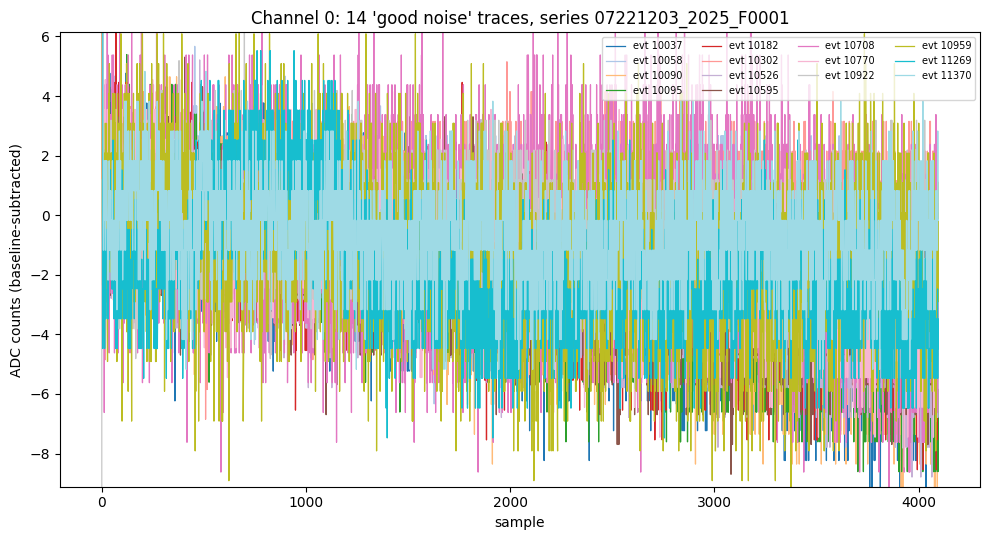

In [2]:
subtracted = op.baseline_subtract(pulses, config)

ylo, yhi = np.percentile(subtracted, [0.5, 99.5])
pad = 0.15 * (yhi - ylo)

colors = plt.cm.tab20(np.linspace(0, 1, len(events)))

fig, ax = plt.subplots(figsize=(10, 5.5))
for trace, event, color in zip(subtracted, events, colors):
    ax.plot(trace, linewidth=0.9, color=color, label=f"evt {event}")

ax.set_ylim(ylo - pad, yhi + pad)
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Channel {CHANNEL}: {len(events)} 'good noise' traces, series 07221203_2025_F0001")
ax.legend(fontsize=7, ncol=4, loc="upper right")
fig.tight_layout()
plt.show()

## FFT of all traces, compared

Take the real FFT (`np.fft.rfft`) of every one of the traces shown above and overlay
all of their real and imaginary parts on one pair of axes, using the same
per-event colors as the overlay plot.

Notes:
- The true ADC sample rate for this readout isn't established anywhere in the repo or
  run log, so the x-axis here is **normalized frequency** (cycles/sample, 0 to 0.5)
  rather than Hz — trivial to rescale once the real sample rate is known.
- As in the time-domain overlay, the occasional single-sample startup transient leaks
  broadband power into the low-frequency bins; the y-axes are percentile-clipped across
  *all* traces together so the shared spectral shape stays visible.

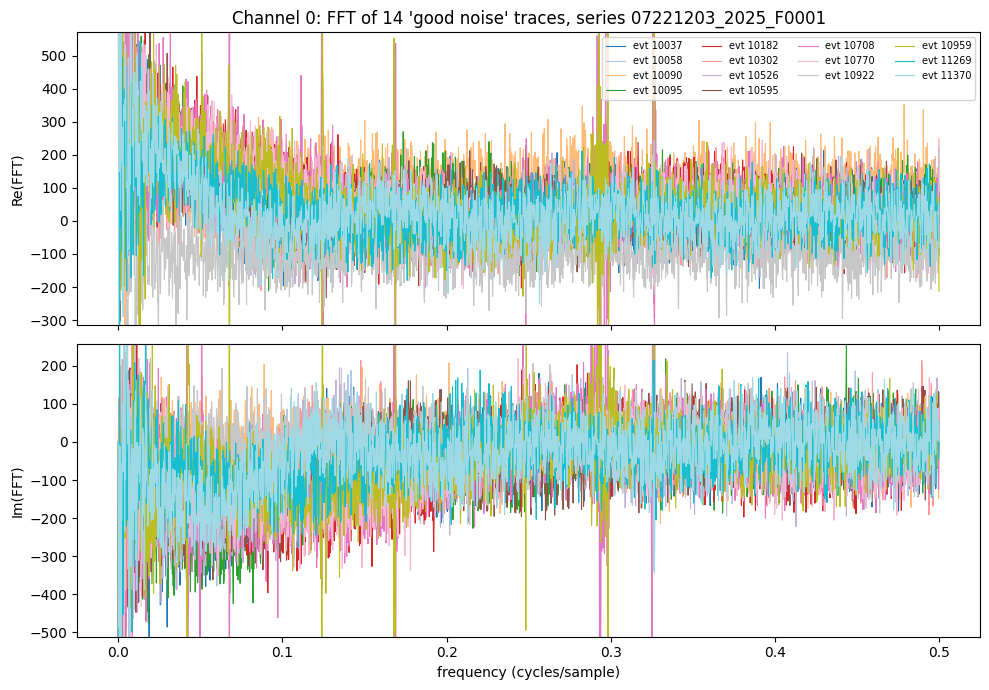

In [3]:
spectra = np.fft.rfft(subtracted, axis=-1)  # raw complex FFT, not wrapped in the library
freqs = np.fft.rfftfreq(subtracted.shape[-1], d=1.0)  # cycles/sample; real sample rate unknown

re_lo, re_hi = np.percentile(spectra.real, [0.5, 99.5])
im_lo, im_hi = np.percentile(spectra.imag, [0.5, 99.5])
re_pad = 0.15 * (re_hi - re_lo)
im_pad = 0.15 * (im_hi - im_lo)

fig, (ax_re, ax_im) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for spectrum, event, color in zip(spectra, events, colors):
    ax_re.plot(freqs, spectrum.real, linewidth=0.8, color=color, label=f"evt {event}")
    ax_im.plot(freqs, spectrum.imag, linewidth=0.8, color=color)

ax_re.set_ylim(re_lo - re_pad, re_hi + re_pad)
ax_re.set_ylabel("Re(FFT)")
ax_re.set_title(f"Channel {CHANNEL}: FFT of {len(events)} 'good noise' traces, series 07221203_2025_F0001")
ax_re.legend(fontsize=7, ncol=4, loc="upper right")

ax_im.set_ylim(im_lo - im_pad, im_hi + im_pad)
ax_im.set_ylabel("Im(FFT)")
ax_im.set_xlabel("frequency (cycles/sample)")

fig.tight_layout()
plt.show()

## Next steps

- Repeat for the other channels represented in the passing set (1 and 3 — channel 2
  never passes the cut at this threshold, worth understanding why).
- If these overlay cleanly as a consistent noise band, they're a reasonable candidate
  set for a per-channel noise PSD (per the original notebook's next-steps note).

## Complex square of the FFTs

For each trace, `spectrum * conj(spectrum)` — the (unnormalized) power spectrum —
plotted for all traces on one log-log axis. The imaginary part of this product is zero
by construction (up to floating-point noise), so only the real part is plotted.

The sample period for this readout is 1.6 us (625 kHz sample rate), so the x-axis here
is real frequency in Hz (log scale — the DC bin is dropped since 0 Hz can't be shown on
a log axis). Both axes are log for this plot, unlike the linear ones above.

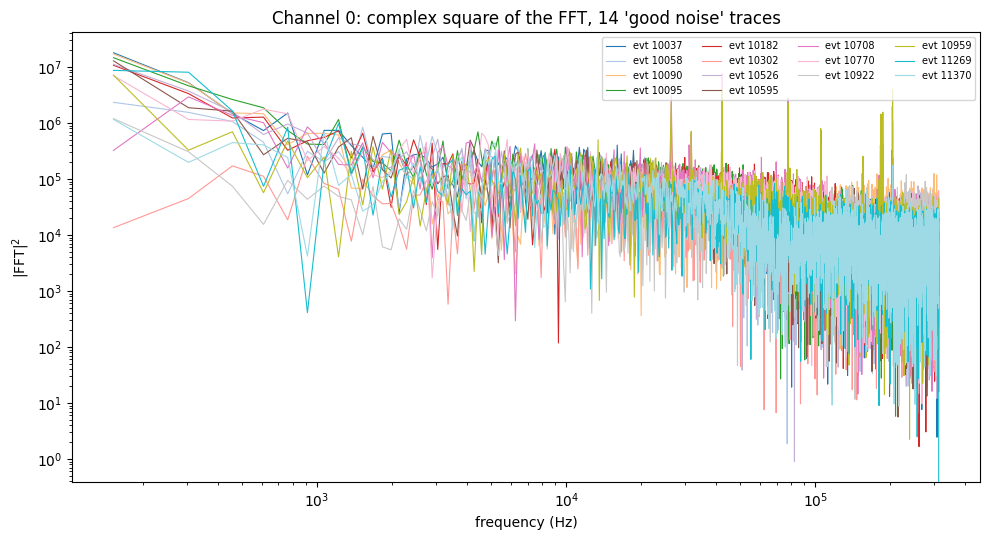

In [4]:
power = pq.power_spectrum(subtracted, config)
freqs_hz = pq.frequencies_hz(subtracted.shape[-1], config)

fig, ax = plt.subplots(figsize=(10, 5.5))

for p, event, color in zip(power, events, colors):
    ax.plot(freqs_hz[1:], p[1:], linewidth=0.8, color=color, label=f"evt {event}")  # drop DC bin (0 Hz) for log x-axis

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"$|\mathrm{FFT}|^2$")
ax.set_title(f"Channel {CHANNEL}: complex square of the FFT, {len(events)} 'good noise' traces")
ax.legend(fontsize=7, ncol=4, loc="upper right")
fig.tight_layout()
plt.show()

## Average power spectrum

Same log-log scale (Hz vs. $|\mathrm{FFT}|^2$, DC bin dropped) as the plot above, but
now averaging the squared-FFT values across all 14 traces at each frequency bin instead
of overlaying them individually — a first-pass noise PSD estimate for this channel.

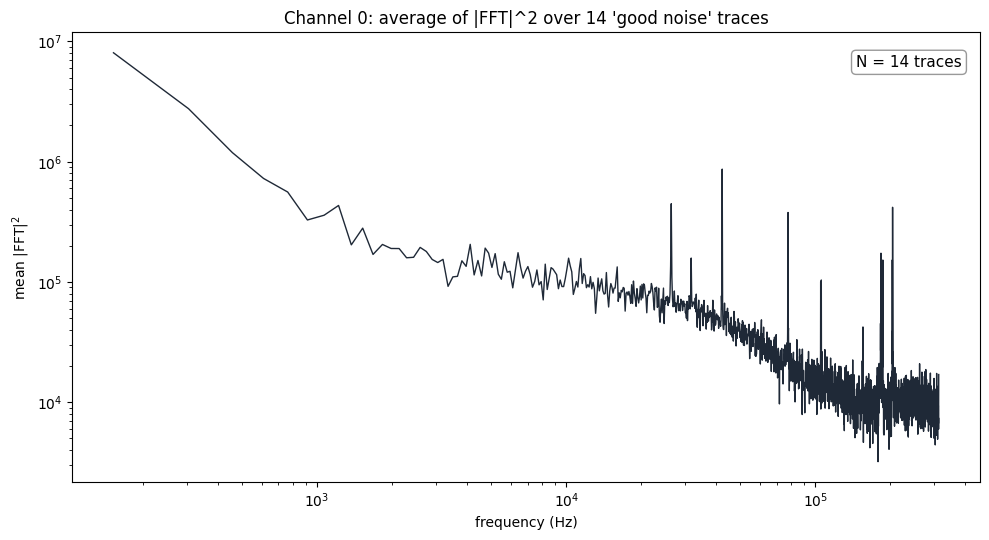

In [5]:
mean_power = power.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(freqs_hz[1:], mean_power[1:], linewidth=1.0, color="#1f2937")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"mean $|\mathrm{FFT}|^2$")
ax.set_title(f"Channel {CHANNEL}: average of |FFT|^2 over {len(events)} 'good noise' traces")
ax.text(0.98, 0.95, f"N = {len(events)} traces", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

## Average PSD by cut: excursion_band vs. excursion_band_loose vs. excursion_band_AI

The sections above used a fixed, precomputed 21-trace "good noise" set from the now-superseded `dump1_noise_pulses.ipynb`. Here instead, load every Detector 0/Channel 0 trace directly and select with the three Branch 2 cuts from `pulse_cuts.py` (07221203_2025_dump1_noise.ipynb) -- `excursion_band` (`[0.5, 0.7)`), `excursion_band_loose` (`[0.5, 1.0)`), and `excursion_band_AI` (`excursion_band` minus traces `looks_like_pulse` judges to contain a real pulse) -- each on the 500-sample pretrigger window those cuts are defined against. Same log-log, DC-bin-dropped average-PSD convention as the single-cut plot above, overlaid for comparison. `excursion_band_AI` is still `under_development` -- see `python/README.md`.

/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_74949/771159461.py:10: UserWarning: excursion_band_AI is marked under_development: excursion_band ([0.5, 0.7) by default) with looks_like_pulse traces removed -- i.e. 'whatever Claude judged to be a real pulse, taken out.' Both the band and the pulse-shape veto are judgment calls; treat this as an exploratory variant of excursion_band, not an independently validated cut, and check what it removes before trusting it on a new dataset.
  "excursion_band_AI": pc.excursion_band_AI(pulses_all, config_500),
/Users/villaa/Research/NSDF-Data/python/pulse_cuts.py:150: UserWarning: looks_like_pulse is marked under_development: 'looks like a pulse' is a judgment call, not a validated physical criterion. Flags traces whose excursion stays near its own peak for a long *consecutive* run (excursion_duration >= min_duration), which a real detector pulse's rise-then-decay does and ordinary noise usually doesn't. default min_duration=50 was picke

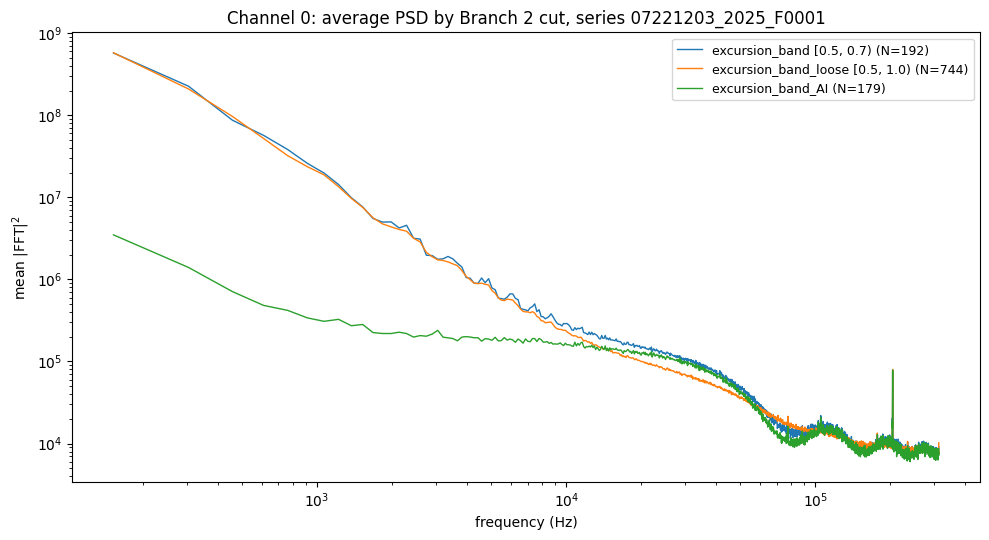

In [6]:
import pulse_cuts as pc

detector0_ids = pio.filter_by_detector(cdms.get_detector_ids(), 0)
_, pulses_all = pio.load_channel_batch(cdms, detector0_ids, CHANNEL)
config_500 = PulseConfig(pretrigger_samples=500, glitch_samples=10, sample_period_s=1.6e-6)

cut_masks = {
    "excursion_band [0.5, 0.7)": pc.excursion_band(pulses_all, config_500),
    "excursion_band_loose [0.5, 1.0)": pc.excursion_band_loose(pulses_all, config_500),
    "excursion_band_AI": pc.excursion_band_AI(pulses_all, config_500),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, mask in cut_masks.items():
    n = mask.sum()
    subset = op.baseline_subtract(pulses_all[mask], config_500)
    power_subset = pq.power_spectrum(subset, config_500)
    freqs_500 = pq.frequencies_hz(subset.shape[-1], config_500)
    mean_power_subset = power_subset.mean(axis=0)
    ax.plot(freqs_500[1:], mean_power_subset[1:], linewidth=1.0, label=f"{label} (N={n})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"mean $|\mathrm{FFT}|^2$")
ax.set_title(f"Channel {CHANNEL}: average PSD by Branch 2 cut, series 07221203_2025_F0001")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

`excursion_band` and `excursion_band_loose` track each other closely but sit 3-4 orders of magnitude above `excursion_band_AI` below ~2 kHz -- a real pulse's rise/decay is low-frequency-dominated, so even the minority of contaminating traces in those two cuts (13/192 and, presumably, more in the wider 744) skew their *mean* PSD far above the noise floor. Removing exactly those traces is what `excursion_band_AI` was built to do, and here it shows up directly as a flatter, lower PSD -- a practical, cut-independent check on the pulse-shape heuristic, on top of the visual check in `07221203_2025_dump1_noise.ipynb`. All three still converge above ~30 kHz, where the noise floor dominates regardless of the cut.